
# Did the Billboard Campaign Actually Work?
### A hands-on Difference-in-Differences (DID) project

**Business problem.** *Beacon*, a fictional food-delivery app, ran offline billboard
campaigns to boost app downloads. Campaigns were **not** randomized — the marketing
team rolled them out city-by-city, region-by-region, based on budget availability. Some
cities got billboards on **2021-05-15**, others on **2021-06-04**, others on
**2021-06-20**, and some cities never got billboards at all (our control group).

Because assignment wasn't random, we can't just compare treated vs. untreated cities —
regions differ in size, growth rate, and culture. But we **do** have daily downloads for
every city both **before and after** the campaigns (a *panel*), which is exactly the
setting where **Difference-in-Differences (DID)** shines.

This notebook is a guided, practical walkthrough that mirrors — and stress-tests — every
technique from *Chapter 8: Difference-in-Differences* (Facure, *Causal Inference in
Python*):

1. Simulate a realistic panel dataset (with a **known ground-truth effect**, so we can
   grade every estimator).
2. **Canonical 2×2 DID** — by hand, by OLS, and by fixed effects.
3. **Inference** — why naive standard errors lie, and how to cluster / block-bootstrap.
4. **Effect dynamics over time** — does the campaign work immediately, or does it ramp up?
5. **Parallel trends** — the assumption behind everything, and how to eyeball it.
6. **DID with covariates** — when trends are only parallel *within* a region.
7. **Doubly Robust DID** — combining a propensity-score model and an outcome model.
8. **Staggered adoption** — the realistic case where cities go live on different dates,
   why naive Two-Way Fixed Effects (TWFE) gets **biased**, and how to fix it.

By the end you'll have a template you can point at any real "rollout" dataset — store
openings, feature launches, policy changes — and a working intuition for *why* each
step matters, not just the code to run.



## 0. Setup

We'll only need `pandas`, `numpy`, `statsmodels`, and `matplotlib`. Everything here also
works with the original book's dataset — we simulate our own so that we know the
**true** treatment effect and can check every estimator against it.


In [1]:

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

np.random.seed(42)
pd.set_option("display.max_rows", 10)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3



## 1. Simulate the panel

We build a **daily city-level panel** from `2021-05-01` to `2021-07-31` (92 days), for
80 cities spread across 4 regions (`E`, `N`, `S`, `W`). Regions differ in:

- **baseline download level** (bigger regions start higher)
- **organic daily growth trend** (some regions are growing faster than others regardless
  of any campaign)

Cities are split into **4 cohorts**:

| Cohort | Go-live date |
|---|---|
| Early | 2021-05-15 |
| Mid | 2021-06-04 |
| Late | 2021-06-20 |
| Never treated | — (control) |

The **true campaign effect is not instantaneous** — it ramps up over ~10 days after
go-live and then plateaus (very common for offline/awareness campaigns), just like the
pattern discussed in the book. We store the true per-row effect `tau` so we can check
our estimators against ground truth — a luxury we'd never have with real data.


In [2]:

N_CITIES_PER_REGION = 20
REGIONS = {
    # region: (baseline_level, daily_trend)
    "E": (18.0, 0.10),
    "N": (28.0, 0.15),
    "S": (38.0, 0.05),
    "W": (23.0, 0.12),
}

dates = pd.date_range("2021-05-01", "2021-07-31", freq="D")
T = len(dates)

# cohorts (go-live date). "2100-01-01" == never treated, matches the book's convention
COHORTS = ["2021-05-15", "2021-06-04", "2021-06-20", "2100-01-01"]
TAU_MAX = 3.0        # long-run (plateau) treatment effect on daily downloads
RAMP_DAYS = 10.0      # days to reach ~63% of the plateau effect

def true_effect(days_since_treat):
    # Ramps up after go-live, 0 before it. Vectorized, overflow-safe.
    x = np.clip(-days_since_treat / RAMP_DAYS, -50, 50)
    eff = TAU_MAX * (1 - np.exp(x))
    return np.where(days_since_treat >= 0, eff, 0.0)

# IMPORTANT: cohorts are assigned *stratified by region* (equal count of each
# cohort within every region). This mirrors good experimental-design practice and
# means treated/control groups have identical region composition -- so any bias we
# find later comes purely from the *staggered timing* mechanism we want to study,
# not from an accidental regional imbalance (regions differ a lot in growth trend).
rows = []
city_id = 0
for region, (level, trend) in REGIONS.items():
    region_cohorts = np.tile(COHORTS, N_CITIES_PER_REGION // len(COHORTS))
    np.random.shuffle(region_cohorts)
    for cohort in region_cohorts:
        city_id += 1
        cohort_date = pd.to_datetime(cohort)
        city_fe = np.random.normal(0, 1.5)          # unobserved, TIME-FIXED city quality
        for t_idx, d in enumerate(dates):
            days_since = (d - cohort_date).days
            tau = true_effect(days_since)
            treated_flag = cohort != "2100-01-01"
            y = (
                level
                + trend * t_idx
                + city_fe
                + tau
                + np.random.normal(0, 1.0)
            )
            rows.append((d, city_id, region, cohort_date, treated_flag, y, tau))

panel = pd.DataFrame(
    rows, columns=["date", "city", "region", "cohort", "treated", "downloads", "tau"]
)
panel.head()


,date,city,region,cohort,treated,downloads,tau
0,2021-05-01,1,E,2021-05-15,True,21.732282,0.0
1,2021-05-02,1,E,2021-05-15,True,17.854461,0.0
2,2021-05-03,1,E,2021-05-15,True,20.997008,0.0
3,2021-05-04,1,E,2021-05-15,True,20.242523,0.0
4,2021-05-05,1,E,2021-05-15,True,20.429700,0.0


In [3]:

# Quick sanity check: how many cities per cohort?
panel.drop_duplicates("city")["cohort"].value_counts().sort_index()


cohort
2021-05-15    20
2021-06-04    20
2021-06-20    20
2100-01-01    20
Name: count, dtype: int64


### 1.1 Visualize the rollout & raw outcome

This is the same kind of "treatment matrix + outcome" plot from the book (Figure 8-2).
It's always worth drawing before touching any regression — it tells you immediately
whether you're dealing with a clean **block design** (one treatment date) or a messier
**staggered adoption design** (several go-live dates).


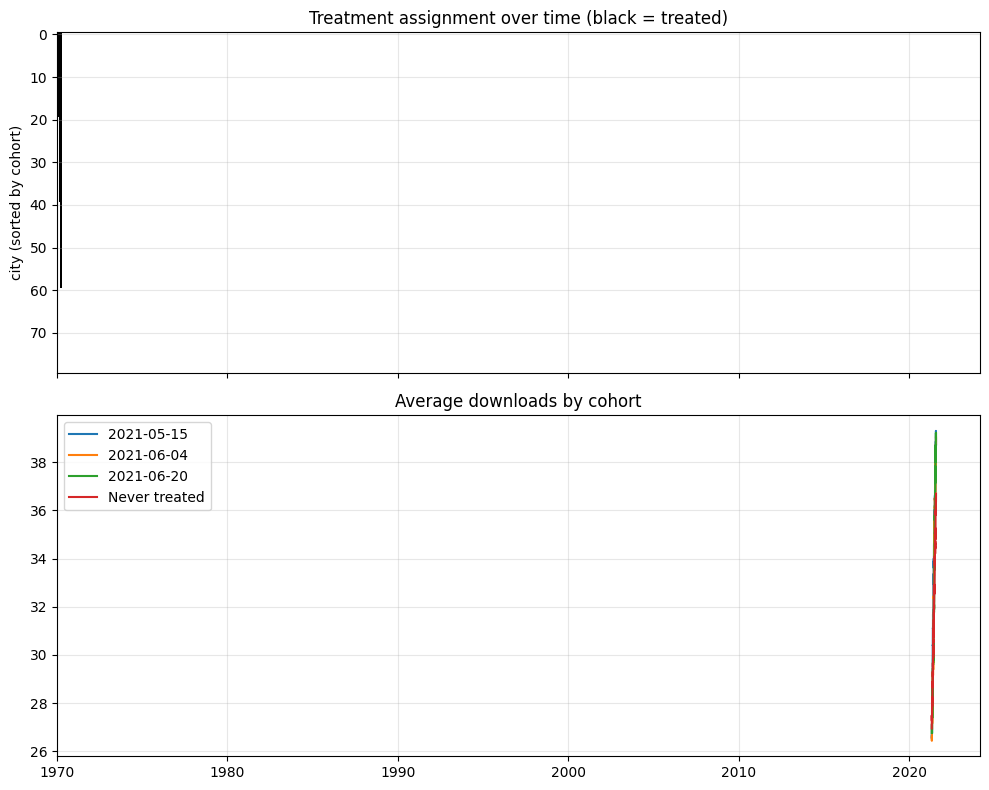

In [4]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Treatment assignment heatmap
pivot = (panel.assign(w=lambda d: (d["date"] >= d["cohort"]).astype(int))
              .pivot(index="city", columns="date", values="w"))
pivot = pivot.loc[panel.sort_values("cohort")["city"].unique()]
axes[0].imshow(pivot.values, aspect="auto", cmap="Greys", interpolation="none")
axes[0].set_title("Treatment assignment over time (black = treated)")
axes[0].set_ylabel("city (sorted by cohort)")

# Outcome by cohort
for cohort, grp in panel.groupby("cohort"):
    label = "Never treated" if cohort == pd.Timestamp("2100-01-01") else cohort.date()
    daily = grp.groupby("date")["downloads"].mean()
    axes[1].plot(daily.index, daily.values, label=str(label))
axes[1].set_title("Average downloads by cohort")
axes[1].legend()
plt.tight_layout()
plt.show()



## 2. Warm-up: canonical 2×2 DID

To learn the mechanics cleanly, let's start EXACTLY like the book does: pretend we only
have **two periods** (pre/post) and **two groups** (the *Early* cohort vs. the *Never
treated* cohort), looking only at the window around the Early cohort's go-live date.
This is the textbook **block design**.


In [5]:

block = panel[panel["cohort"].isin([pd.Timestamp("2021-05-15"), pd.Timestamp("2100-01-01")])].copy()
block = block[(block["date"] >= "2021-05-01") & (block["date"] <= "2021-05-29")]
block["treated_grp"] = (block["cohort"] == pd.Timestamp("2021-05-15")).astype(int)
block["post"] = (block["date"] >= "2021-05-15").astype(int)
block["w"] = block["treated_grp"] * block["post"]

block[["date", "city", "region", "treated_grp", "post", "downloads"]].head()


,date,city,region,treated_grp,post,downloads
0,2021-05-01,1,E,1,0,21.732282
1,2021-05-02,1,E,1,0,17.854461
2,2021-05-03,1,E,1,0,20.997008
3,2021-05-04,1,E,1,0,20.242523
4,2021-05-05,1,E,1,0,20.429700



### 2.1 DID "by hand": the four cell averages

Just like the book: group by `(treated, post)`, take the mean, and combine the four
numbers.


In [6]:

did_data = block.groupby(["treated_grp", "post"]).agg(downloads=("downloads", "mean"))
did_data


downloads
treated_grp post           
0           0     27.750329
            1     29.208694
1           0     27.254787
            1     30.229165

In [7]:

# counterfactual Y(0) for the treated group in the post period:
# treated baseline + control's growth
y0_est = (
    did_data.loc[1].loc[0, "downloads"]
    + (did_data.loc[0].loc[1, "downloads"] - did_data.loc[0].loc[0, "downloads"])
)
att_by_hand = did_data.loc[1].loc[1, "downloads"] - y0_est
print(f"DID ATT (by hand):        {att_by_hand:.4f}")

true_att_block = block.query("post==1 and treated_grp==1")["tau"].mean()
print(f"True ATT (post, treated): {true_att_block:.4f}")


DID ATT (by hand):        1.5160
True ATT (post, treated): 1.3673



### 2.2 DID via OLS regression

Regressing `downloads ~ treated_grp * post` recovers the exact same number as the
`treated_grp:post` coefficient — but now we get standard errors, and it's trivial to
extend with more controls.


In [8]:

m_ols = smf.ols("downloads ~ treated_grp * post", data=block).fit()
print("DID ATT (OLS):", m_ols.params["treated_grp:post"])
m_ols.summary().tables[1]


DID ATT (OLS): 1.5160125511049198


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,27.7503,0.431,64.317,0.000,26.904,28.597
treated_grp,-0.4955,0.610,-0.812,0.417,-1.693,0.702
post,1.4584,0.600,2.431,0.015,0.281,2.635
treated_grp:post,1.5160,0.848,1.787,0.074,-0.149,3.181



### 2.3 DID via Two-Way Fixed Effects (TWFE)

Instead of two dummies, we can absorb *every* city and *every* date as fixed effects.
With a clean 2×2 block design this recovers the identical ATT.


In [9]:

m_twfe = smf.ols(
    "downloads ~ treated_grp:post + C(city) + C(date)", data=block
).fit()
print("DID ATT (TWFE):", m_twfe.params["treated_grp:post"])


DID ATT (TWFE): 1.5160125511049025



## 3. Inference: why the naive standard errors are wrong

We have `N * T` rows, but they are **not independent** — the same city shows up on
every date, and treatment is assigned at the **city** level, not the date level. The
effective sample size is closer to the *number of cities* than the number of rows.

The fix: **cluster standard errors by city**, or use a **block bootstrap** (resample
whole cities, with replacement, rather than individual rows).


In [10]:

m_naive = smf.ols("downloads ~ treated_grp:post + C(city) + C(date)", data=block).fit()
m_clustered = smf.ols(
    "downloads ~ treated_grp:post + C(city) + C(date)", data=block
).fit(cov_type="cluster", cov_kwds={"groups": block["city"]})

print("Naive 95% CI:    ", m_naive.conf_int().loc["treated_grp:post"].values)
print("Clustered 95% CI:", m_clustered.conf_int().loc["treated_grp:post"].values)


Naive 95% CI:     [1.26179927 1.77022583]
Clustered 95% CI: [1.10459662 1.92742848]


In [11]:

def block_sample(df, unit_col):
    units = df[unit_col].unique()
    sample = np.random.choice(units, size=len(units), replace=True)
    return (
        df.set_index(unit_col)
          .loc[sample]
          .reset_index(level=[unit_col])
    )

def est_fn(df):
    m = smf.ols("downloads ~ treated_grp:post + C(city) + C(date)", data=df).fit()
    return m.params["treated_grp:post"]

def block_bootstrap(data, est_fn, unit_col, rounds=150, seed=123, pcts=(2.5, 97.5)):
    np.random.seed(seed)
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(block_sample(data, unit_col)) for _ in range(rounds)
    )
    return np.percentile(stats, pcts)

boot_ci = block_bootstrap(block, est_fn, "city")
print("Block-bootstrap 95% CI:", boot_ci)


Block-bootstrap 95% CI: [1.16826576 1.8972993 ]



**Takeaway:** the clustered and bootstrapped intervals are both noticeably wider than
the naive one. Always cluster (at minimum) by the unit that received treatment.



## 4. Effect dynamics: does the campaign kick in immediately?

We simulated a **ramping** effect on purpose. If we only compute one aggregate ATT, we
average together the "not-yet-mature" days with the "fully matured" days and understate
the eventual impact. The book's trick: run a 2×2 DID for *every* possible post date
(pretending only that date is "post"), including a placebo run through the pre-period.


In [12]:

def did_date(df, date):
    df_date = (
        df.query("date == @date or post == 0")
          .query("date <= @date")
          .assign(post=lambda d: (d["date"] == date).astype(int))
    )
    m = smf.ols(
        "downloads ~ treated_grp:post + C(city) + C(date)", data=df_date
    ).fit(cov_type="cluster", cov_kwds={"groups": df_date["city"]})
    att = m.params["treated_grp:post"]
    ci = m.conf_int().loc["treated_grp:post"]
    return pd.DataFrame({"att": att, "ci_low": ci[0], "ci_up": ci[1]}, index=[date])

all_dates = sorted(block["date"].unique())[1:]
atts_over_time = pd.concat([did_date(block, d) for d in all_dates])
atts_over_time.head()


,att,ci_low,ci_up
2021-05-02,-0.670110,-2.086556,0.746337
2021-05-03,0.154449,-0.592238,0.901135
2021-05-04,0.227551,-0.699808,1.154910
2021-05-05,0.235891,-0.598034,1.069817
2021-05-06,-0.832513,-1.530489,-0.134537


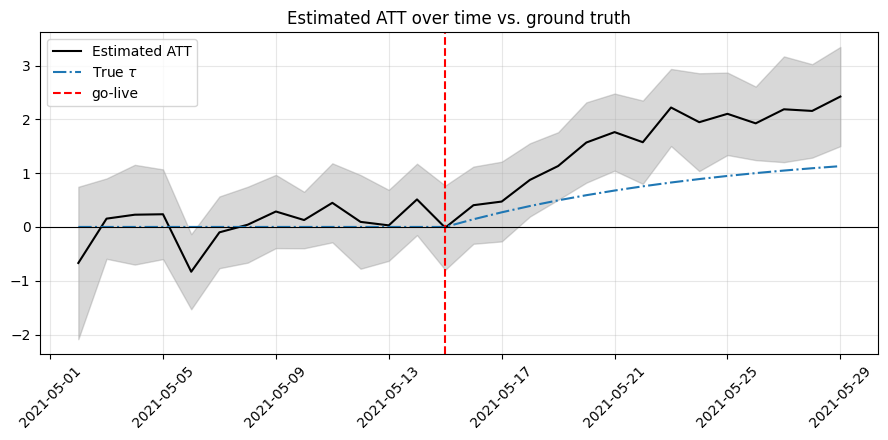

In [13]:

true_tau_over_time = (
    block.groupby("date")["tau"].mean().reindex(atts_over_time.index)
)

fig, ax = plt.subplots()
ax.plot(atts_over_time.index, atts_over_time["att"], color="black", label="Estimated ATT")
ax.fill_between(atts_over_time.index, atts_over_time["ci_low"], atts_over_time["ci_up"],
                 color="gray", alpha=0.3)
ax.plot(true_tau_over_time.index, true_tau_over_time.values, "-.", color="tab:blue", label=r"True $\tau$")
ax.axvline(pd.Timestamp("2021-05-15"), ls="--", color="red", label="go-live")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
ax.set_title("Estimated ATT over time vs. ground truth")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Two things to notice, both echoed in the book:

1. **Pre-period estimates hover around zero** — reassuring evidence for the
   **no-anticipation** assumption (the effect isn't showing up before the campaign
   even starts).
2. **Post-period estimates climb gradually** rather than jumping immediately — exactly
   the ramp we built into the simulation. A single aggregate ATT would understate the
   long-run effect.



## 5. Parallel trends: eyeballing the key assumption

DID's entire identification strategy rests on **parallel trends**: absent treatment,
treated and control cities would have moved together. It's untestable in the
post-period (we never observe the counterfactual), but we *can* check it in the
pre-period as supporting evidence.


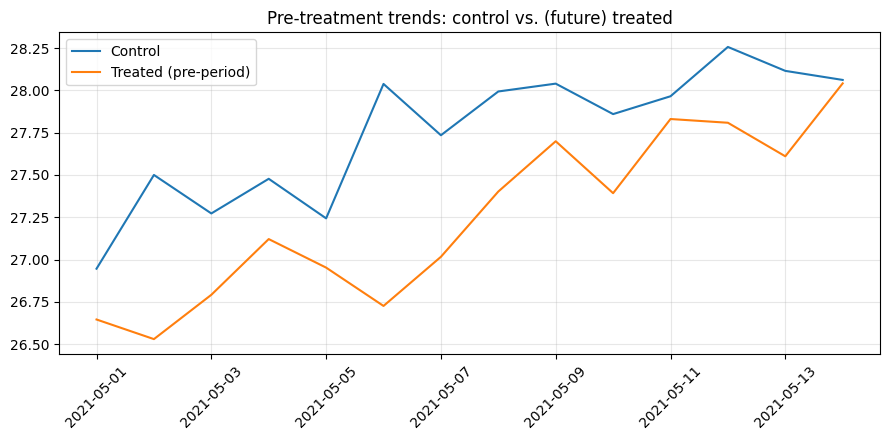

In [14]:

pre = block.query("post == 0").groupby(["date", "treated_grp"])["downloads"].mean().unstack()
fig, ax = plt.subplots()
ax.plot(pre.index, pre[0], label="Control")
ax.plot(pre.index, pre[1], label="Treated (pre-period)")
ax.set_title("Pre-treatment trends: control vs. (future) treated")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



The two lines move together before go-live — good evidence that, absent the campaign,
they'd have kept moving together. **Warning from the book, worth repeating**: parallel
trends is **not scale-invariant**. If you log-transform the outcome (e.g., to talk about
percentage effects), trends that look parallel in levels can look convergent in logs,
and vice-versa. Always check the assumption on the same scale you intend to estimate on.



## 6. DID with covariates: when trends are only parallel *within* a region

Now let's use the **full dataset**, still restricted to the Early cohort vs.
Never-treated, but across **all four regions**. Regions grow at different organic
rates — so trends are parallel *within* a region but not *across* regions. A naive
region-blind TWFE will be biased.


In [15]:

full_block = panel[panel["cohort"].isin([pd.Timestamp("2021-05-15"), pd.Timestamp("2100-01-01")])].copy()
full_block = full_block[(full_block["date"] >= "2021-05-01") & (full_block["date"] <= "2021-05-29")]
full_block["treated_grp"] = (full_block["cohort"] == pd.Timestamp("2021-05-15")).astype(int)
full_block["post"] = (full_block["date"] >= "2021-05-15").astype(int)

# NOTE: by design, our simulated dataset stratifies treatment by region, so treated
# and control groups already have matched regional composition. To actually
# demonstrate the "trends only parallel *within* region" problem from the book, we
# recreate a *realistic marketing scenario*: the marketing team concentrated the
# billboard campaign more heavily in the slower-growing regions (S, E) -- e.g.
# because those markets had more headroom -- while the untouched control cities are
# disproportionately in the faster-growing regions (N, W). This kind of selection is
# extremely common in real rollouts and is exactly what makes naive TWFE dangerous.
rng = np.random.RandomState(7)
city_region = full_block.drop_duplicates("city")[["city", "treated_grp", "region"]]
slow, fast = ["S", "E"], ["N", "W"]

def biased_keep(row):
    # Treated cities: 85% chance of being kept if slow-growth, 25% if fast-growth.
    # Control cities: 85% chance of being kept if fast-growth, 25% if slow-growth.
    p_keep = 0.85 if (row["region"] in slow) == (row["treated_grp"] == 1) else 0.25
    return rng.rand() < p_keep

keep_mask = city_region.apply(biased_keep, axis=1)
keep_cities = city_region.loc[keep_mask, "city"]
full_block = full_block[full_block["city"].isin(keep_cities)].copy()
full_block.drop_duplicates("city").groupby(["treated_grp", "region"]).size()

true_att_full = full_block.query("post==1 and treated_grp==1")["tau"].mean()

# naive TWFE, ignoring the fact that regions grow at different rates
m_naive_region = smf.ols(
    "downloads ~ treated_grp:post + C(city) + C(date)", data=full_block
).fit()

print(f"True ATT:                {true_att_full:.4f}")
print(f"Naive TWFE ATT (biased): {m_naive_region.params['treated_grp:post']:.4f}")


True ATT:                1.3673
Naive TWFE ATT (biased): 0.9301



As the book warns: simply *adding* `region` as a covariate does **nothing** here,
because unit fixed effects already absorb any time-fixed covariate (region is constant
within a city). What actually fixes this is letting **region interact with time**, so
each region gets its own trend:


In [16]:

m_saturated = smf.ols(
    "downloads ~ post*(treated_grp + C(region)) + C(city)", data=full_block
).fit()
att_corrected = m_saturated.params["post:treated_grp"]

print(f"True ATT:                     {true_att_full:.4f}")
print(f"Region-trend-corrected ATT:   {att_corrected:.4f}")


True ATT:                     1.3673
Region-trend-corrected ATT:   1.4573



Much closer to the truth. The lesson generalizes: whenever you suspect parallel trends
only holds *conditional on* some covariate `X` (region, city size, prior growth...),
interact `X` with the time dimension — not just add it as a plain control.



## 7. Doubly Robust DID (DRDID)

A more flexible way to condition on covariates: combine a **propensity score model**
(who gets treated, given covariates) with an **outcome model** (how much would `Δy`
change, given covariates) — you only need ONE of the two to be correctly specified for
the estimate to be unbiased ("doubly robust").


In [17]:

# 1) unit-level table (one row per city) with pre-treatment covariates
unit_df = (
    full_block.astype({"date": str})
              .query("date == date.min()")
              .drop(columns=["date"])
)
ps_model = smf.logit("treated_grp ~ C(region)", data=unit_df).fit(disp=False, maxiter=200, method="bfgs")

# 2) delta-outcome model
delta_y = (
    full_block.query("post==1").groupby("city")["downloads"].mean()
    - full_block.query("post==0").groupby("city")["downloads"].mean()
)
df_delta = unit_df.set_index("city").join(delta_y.rename("delta_y"))
outcome_model = smf.ols("delta_y ~ C(region)", data=df_delta).fit()

# 3) combine
df_dr = df_delta.assign(
    y_hat=lambda d: outcome_model.predict(d),
    ps=lambda d: ps_model.predict(d),
)

tr = df_dr.query("treated_grp == 1")
co = df_dr.query("treated_grp == 0")

dy1 = (tr["delta_y"] - tr["y_hat"]).mean()
w_co = co["ps"] / (1 - co["ps"])
dy0 = np.average(co["delta_y"] - co["y_hat"], weights=w_co)

att_dr = dy1 - dy0
print(f"True ATT:      {true_att_full:.4f}")
print(f"DRDID ATT:     {att_dr:.4f}")


True ATT:      1.3673
DRDID ATT:     1.0795



## 8. The real challenge: staggered adoption

Now let's use the **entire panel**: all 80 cities, all 4 regions, all 4 cohorts (Early,
Mid, Late, Never), full 92-day window. This is a **staggered adoption design** — cities
go live on different dates — and it's where naive TWFE quietly breaks.


In [18]:

full = panel.copy()
full["treated"] = full["cohort"] != pd.Timestamp("2100-01-01")

true_att_all = full.query("treated and date >= cohort")["tau"].mean()
print(f"True overall ATT (all treated cities, all post periods): {true_att_all:.4f}")


True overall ATT (all treated cities, all post periods): 2.4719


In [19]:

full["post"] = (full["date"] >= full["cohort"]).astype(int)
full["w"] = full["treated"].astype(int) * full["post"]

m_twfe_naive = smf.ols(
    "downloads ~ w + C(city) + C(date)", data=full
).fit()

print(f"True ATT:               {true_att_all:.4f}")
print(f"Naive TWFE ATT:          {m_twfe_naive.params['w']:.4f}")
print("--> Notice the bias. This is the classic staggered-adoption TWFE problem.")


True ATT:               2.4719
Naive TWFE ATT:          1.9450
--> Notice the bias. This is the classic staggered-adoption TWFE problem.



### 8.1 Why does this happen?

TWFE implicitly runs many 2×2 DIDs and averages them — **including comparisons where an
already-treated cohort is used as the "control"** for a later cohort. Since our effect
**ramps up over time** (heterogeneous across time), the "control" cohort's trend is
artificially steep — it's still climbing towards its own plateau — which biases the
comparison. This is exactly the mechanism Goodman-Bacon's decomposition explains.

Let's see it directly: compare the *Mid* cohort against the *Late* cohort in both
directions.


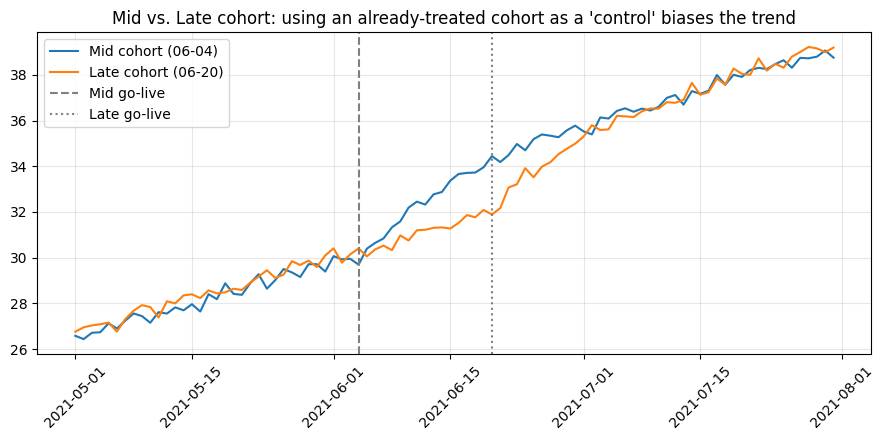

In [20]:

mid_late = full[full["cohort"].isin([pd.Timestamp("2021-06-04"), pd.Timestamp("2021-06-20")])]
daily = mid_late.groupby(["date", "cohort"])["downloads"].mean().unstack()

fig, ax = plt.subplots()
ax.plot(daily.index, daily[pd.Timestamp("2021-06-04")], label="Mid cohort (06-04)")
ax.plot(daily.index, daily[pd.Timestamp("2021-06-20")], label="Late cohort (06-20)")
ax.axvline(pd.Timestamp("2021-06-04"), ls="--", color="gray", label="Mid go-live")
ax.axvline(pd.Timestamp("2021-06-20"), ls=":", color="gray", label="Late go-live")
ax.legend()
ax.set_title("Mid vs. Late cohort: using an already-treated cohort as a 'control' biases the trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Between 06-04 and 06-20, the *Mid* cohort (our would-be "control" for the *Late*
cohort in a naive TWFE) is **already climbing towards its own plateau effect** — its
trend is not a valid stand-in for the counterfactual "no treatment" trend. That's the
leak that biases the aggregate TWFE estimate.



### 8.2 Fix #1 — never-treated as control, one 2×2 DID per cohort

The cleanest fix: for each treated cohort, run its own clean 2×2 DID **against the
never-treated group only**, then combine the cohort-level ATTs with a size-weighted
average (this mirrors the Callaway & Sant'Anna approach cited in the book).


In [21]:

cohorts_treated = sorted(full.query("treated")["cohort"].unique())
never_treated = pd.Timestamp("2100-01-01")

def did_cohort_vs_never(df, cohort, never_treated):
    sub = df[(df["cohort"] == cohort) | (df["cohort"] == never_treated)].copy()
    sub["treated_grp"] = (sub["cohort"] == cohort).astype(int)
    sub["post"] = (sub["date"] >= cohort).astype(int)
    m = smf.ols("downloads ~ treated_grp*post", data=sub).fit()
    att = m.params["treated_grp:post"]
    n = sub.query("treated_grp == 1 and post == 1").shape[0]
    return {"cohort": cohort, "att_g": att, "size": n}

cohort_atts = pd.DataFrame(
    [did_cohort_vs_never(full, g, never_treated) for g in cohorts_treated]
)
cohort_atts


,cohort,att_g,size
0,2021-05-15,2.740649,1560
1,2021-06-04,2.504754,1160
2,2021-06-20,2.296331,840


In [22]:

weighted_att = (cohort_atts["att_g"] * cohort_atts["size"]).sum() / cohort_atts["size"].sum()
print(f"True ATT:                          {true_att_all:.4f}")
print(f"Naive TWFE ATT (biased):           {m_twfe_naive.params['w']:.4f}")
print(f"Cohort-by-cohort weighted ATT:     {weighted_att:.4f}")


True ATT:                          2.4719
Naive TWFE ATT (biased):           1.9450
Cohort-by-cohort weighted ATT:     2.5589



### 8.3 Fix #2 — saturated cohort × time interaction (Sun & Abraham style)

Alternative fix within a single regression: instead of one `w` coefficient, let the
effect vary by **cohort AND calendar date** (`treated:C(cohort):C(date)`). This uses
far more parameters, but it never lets an already-treated cohort's changing effect
contaminate another cohort's estimate.


In [23]:

formula = "downloads ~ treated:post:C(cohort):C(date) + C(city) + C(date)"
m_saturated_stagger = smf.ols(formula, data=full).fit()

# Recover the implied individual treatment effect for every treated, post-period row
pred = full.query("post == 1 and treated").copy()
pred["y_hat_0"] = m_saturated_stagger.predict(pred.assign(treated=False))
pred["effect_hat"] = pred["downloads"] - pred["y_hat_0"]

print("Number of parameters:", len(m_saturated_stagger.params))
print(f"True ATT:                        {true_att_all:.4f}")
print(f"Saturated cohort x time ATT:      {pred['effect_hat'].mean():.4f}")


Number of parameters: 907
True ATT:                        2.4719
Saturated cohort x time ATT:      2.5298


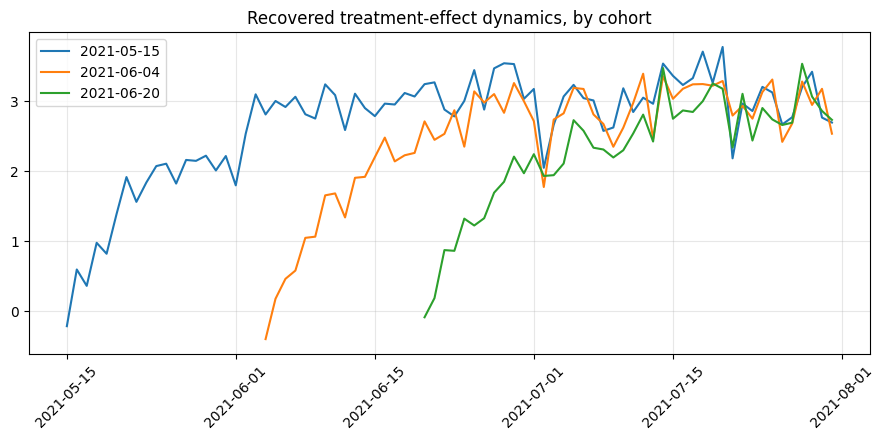

In [24]:

# and we can plot the recovered effect dynamics per cohort - it should show the same
# ramp-up pattern we built into the simulation, separately for each cohort
fig, ax = plt.subplots()
for cohort, grp in pred.groupby("cohort"):
    daily_eff = grp.groupby("date")["effect_hat"].mean()
    ax.plot(daily_eff.index, daily_eff.values, label=str(cohort.date()))
ax.set_title("Recovered treatment-effect dynamics, by cohort")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 9. Scorecard: every estimator vs. the truth

Let's line everything up side by side. This is the kind of sanity-check table you
should build any time you're not 100% sure which estimator is trustworthy for your
data's design.


In [25]:

scorecard = pd.DataFrame([
    {"method": "2x2 DID by hand (Early vs Never)",           "att": att_by_hand,             "true": true_att_block},
    {"method": "2x2 DID via OLS",                             "att": m_ols.params["treated_grp:post"], "true": true_att_block},
    {"method": "2x2 DID via TWFE",                            "att": m_twfe.params["treated_grp:post"], "true": true_att_block},
    {"method": "Naive TWFE ignoring region trends",           "att": m_naive_region.params["treated_grp:post"], "true": true_att_full},
    {"method": "Region-trend-corrected DID",                  "att": att_corrected,            "true": true_att_full},
    {"method": "Doubly Robust DID",                            "att": att_dr,                   "true": true_att_full},
    {"method": "Naive TWFE, staggered adoption (BIASED)",     "att": m_twfe_naive.params["w"], "true": true_att_all},
    {"method": "Cohort-by-cohort vs never-treated (fixed)",   "att": weighted_att,             "true": true_att_all},
    {"method": "Saturated cohort x time TWFE (fixed)",        "att": pred["effect_hat"].mean(),"true": true_att_all},
])
scorecard["abs_error"] = (scorecard["att"] - scorecard["true"]).abs()
scorecard.round(4)


,method,att,true,abs_error
0,2x2 DID by hand (Early vs Never),1.5160,1.3673,0.1487
1,2x2 DID via OLS,1.5160,1.3673,0.1487
2,2x2 DID via TWFE,1.5160,1.3673,0.1487
3,Naive TWFE ignoring region trends,0.9301,1.3673,0.4372
4,Region-trend-corrected DID,1.4573,1.3673,0.0900
5,Doubly Robust DID,1.0795,1.3673,0.2878
6,"Naive TWFE, staggered adoption (BIASED)",1.9450,2.4719,0.5269
7,Cohort-by-cohort vs never-treated (fixed),2.5589,2.4719,0.0870
8,Saturated cohort x time TWFE (fixed),2.5298,2.4719,0.0579



## 10. Key takeaways

1. **DID relaxes unconfoundedness to *conditional parallel trends*** — you don't need
   treatment to be independent of potential outcomes, only for the *growth* in outcomes
   to be independent of treatment. This is much more plausible with unobserved,
   **time-fixed** confounders (culture, regulation, baseline city quality).
2. **Canonical (2×2, block-design) DID is nonparametric and robust** — by-hand averages,
   OLS, and TWFE all agree exactly.
3. **Standard errors need clustering** at the treated unit's level (or a block
   bootstrap) — naive OLS standard errors are systematically too small.
4. **Effect dynamics matter.** A single aggregate ATT can understate a slow-ramping
   effect. Estimating effects period-by-period (and checking the pre-period is flat)
   both quantifies the ramp and validates the no-anticipation assumption.
5. **Covariates must interact with time**, not just be added as controls — unit fixed
   effects wipe out any variable that's constant within a unit.
6. **Staggered adoption is where naive TWFE breaks.** When treatment timing varies
   *and* effects change over time, TWFE implicitly uses already-treated units as
   controls for later cohorts, which biases the estimate — sometimes severely. Always:
   - **plot** the treatment-assignment matrix first to know if you're in a staggered
     design, and
   - use a design that avoids "already-treated" controls: cohort-by-cohort comparisons
     against a never-treated (or not-yet-treated) group, or a saturated
     cohort × time interaction model.

### Where to go from here
- Try shrinking `RAMP_DAYS` to near 0 (an instantaneous effect) and re-run Section 8 —
  the naive TWFE bias should shrink dramatically, confirming that the bias is driven by
  *effect heterogeneity over time*, not staggered timing alone.
- Swap the *never-treated* control group for a *not-yet-treated* group in Section 8.2
  to see how it changes precision.
- Plug in a real dataset: any panel with a `unit`, `date`, `treated_cohort_date`, and
  `outcome` column can be dropped straight into the functions in Sections 2 and 8.
